# Notebook 1
**Exploración inicial de datos**

In [103]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr, kendalltau
import plotly.graph_objects as go
import plotly.express as px
from itertools import combinations
from pathlib import Path
import re
import math
import itertools
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [99]:
data = pd.read_csv(r'C:\Users\Maria Paula\OneDrive\Documents\GitHub\Reto_Topo\DataFrameBabyFaceValidacion.csv')
df = pd.DataFrame(data)

**Limpieza de datos (misma que jorge)**

In [115]:
DATA_CANDIDATES = [
    Path(r"C:\Users\Maria Paula\OneDrive\Documents\GitHub\Reto_Topo\DataFrameBabyFaceValidacion.csv"),
    Path("/mnt/data/DataFrameBabyFaceValidacion.xlsx"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró DataFrameBabyFaceValidacion.xlsx. Coloca el Excel en la misma carpeta del notebook.")

OUTPUT_DIR = Path("babyface_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

MISSING_TOKENS = {'', '-', 'NA', 'NA ', 'N/A', 'nan', 'NaN', 'FIT_FAILED', 'FIT FAILED', 'FIND_FAILED', 'S/I', None}

def parse_time_to_seconds(x):
    """Convierte tiempos a segundos. Maneja segundos, milisegundos y formatos tipo HH:MM:SS.mmm."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        value = float(x)
        # Algunos registros están en milisegundos: 16433 -> 16.433 s.
        return value / 1000 if value > 1000 else value
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    if ':' in s:
        try:
            parts = [p.strip() for p in s.split(':')]
            if len(parts) == 3:
                h, m, sec = parts
                return float(h) * 3600 + float(m) * 60 + float(sec)
            if len(parts) == 2:
                m, sec = parts
                return float(m) * 60 + float(sec)
        except Exception:
            pass
    # Casos como 1.00.60 o 1,34,033: se interpretan como minutos, segundos y fracción.
    if re.fullmatch(r'\d+[\.,]\d+[\.,]\d+', s):
        nums = [int(p) for p in re.split(r'[\.,]', s)]
        if len(nums) == 3:
            minutes, seconds, frac = nums
            return minutes * 60 + seconds + frac / (10 ** len(str(frac)))
    try:
        value = float(s.replace(',', '.'))
        return value / 1000 if value > 1000 else value
    except Exception:
        return np.nan

def parse_numeric(x):
    """Convierte a float y manda tokens de error/missing a NaN."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    try:
        return float(s.replace(',', '.'))
    except Exception:
        return np.nan

def parse_day_number(x):
    """Extrae el número de día de etiquetas mixtas como 7E, 7P, 1E 2, 4.2."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    match = re.search(r'\d+(?:\.\d+)?', s)
    return float(match.group(0)) if match else np.nan

def parse_phase(x):
    """Extrae si la etiqueta de día tiene E, P, ambas o ninguna."""
    if pd.isna(x):
        return "sin_fase"
    s = str(x).strip().upper()
    if s in MISSING_TOKENS:
        return "sin_fase"
    has_e = 'E' in s
    has_p = 'P' in s
    if has_e and has_p:
        return "E/P"
    if has_e:
        return "E"
    if has_p:
        return "P"
    return "sin_fase"

def load_and_clean(path=DATA_PATH):
    raw = pd.read_csv(path)
    df = raw.copy()

    # Normalización de comentarios y día.
    df['comentarios'] = df['comentarios'].replace({'NA': np.nan, 'NA ': np.nan, '-': np.nan})
    df['dia_original'] = df['dia'].astype(str)
    df['dia_num'] = df['dia'].apply(parse_day_number)
    df['fase_dia'] = df['dia'].apply(parse_phase)

    time_cols = ['t_total', 't_prueba1', 't_prueba2']
    binary_cols = ['rechaza', 'llora', 'toca', 'prueba', 'consume']
    va_cols = [c for c in df.columns if c.startswith('valence') or c.startswith('arousal')]

    for c in time_cols:
        df[c] = df[c].apply(parse_time_to_seconds)
    for c in binary_cols:
        df[c] = df[c].apply(parse_numeric)
    for c in va_cols:
        df[c] = df[c].apply(parse_numeric)

    valence_cols = [c for c in df.columns if c.startswith('valence')]
    arousal_cols = [c for c in df.columns if c.startswith('arousal')]

    # Variables derivadas para EDA y TDA.
    df['valence_mean'] = df[valence_cols].mean(axis=1, skipna=True)
    df['arousal_mean'] = df[arousal_cols].mean(axis=1, skipna=True)
    df['valence_delta'] = df['valence_final'] - df['valence_inicio']
    df['arousal_delta'] = df['arousal_final'] - df['arousal_inicio']
    df['valence_p1_delta'] = df['valence_p1_after'] - df['valence_p1_before']
    df['valence_p2_delta'] = df['valence_p2_after'] - df['valence_p2_before']
    df['arousal_p1_delta'] = df['arousal_p1_after'] - df['arousal_p1_before']
    df['arousal_p2_delta'] = df['arousal_p2_after'] - df['arousal_p2_before']
    df['aceptacion_score'] = df[['prueba','consume']].mean(axis=1, skipna=True) - df[['rechaza','llora']].mean(axis=1, skipna=True)
    df['va_missing_count'] = df[valence_cols + arousal_cols].isna().sum(axis=1)
    return raw, df

raw, df_limpio = load_and_clean()
print(f"Archivo cargado: {DATA_PATH}")
print(f"Dimensiones raw: {raw.shape[0]} filas x {raw.shape[1]} columnas")
print(f"Dimensiones cleaned: {df.shape[0]} filas x {df.shape[1]} columnas")

Archivo cargado: C:\Users\Maria Paula\OneDrive\Documents\GitHub\Reto_Topo\DataFrameBabyFaceValidacion.csv
Dimensiones raw: 366 filas x 27 columnas
Dimensiones cleaned: 366 filas x 27 columnas


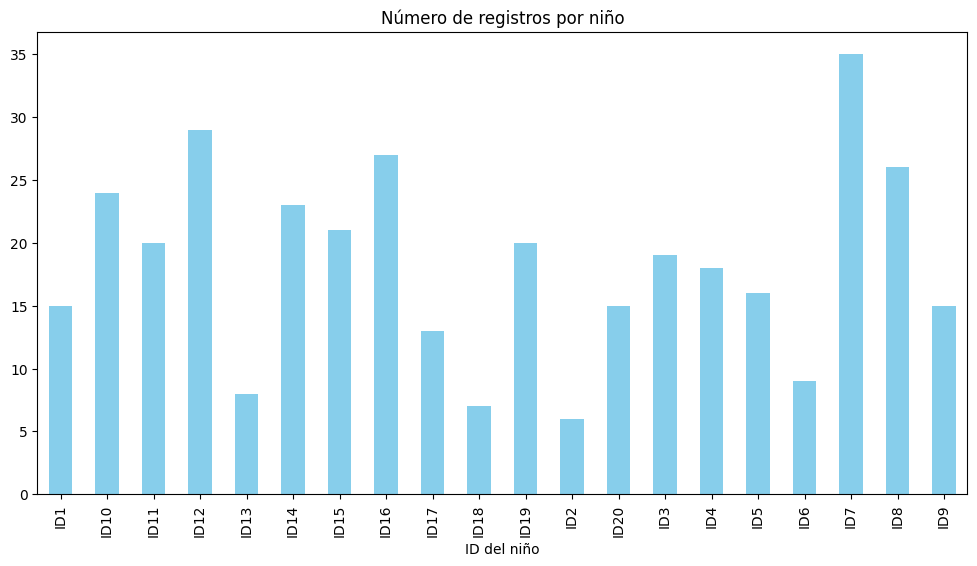

In [116]:
data_per_child = df_limpio.groupby('id').size()
data_per_child.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Número de registros por niño')
plt.xlabel('ID del niño')
plt.show()

In [88]:
data_per_child.mean()

np.float64(18.3)

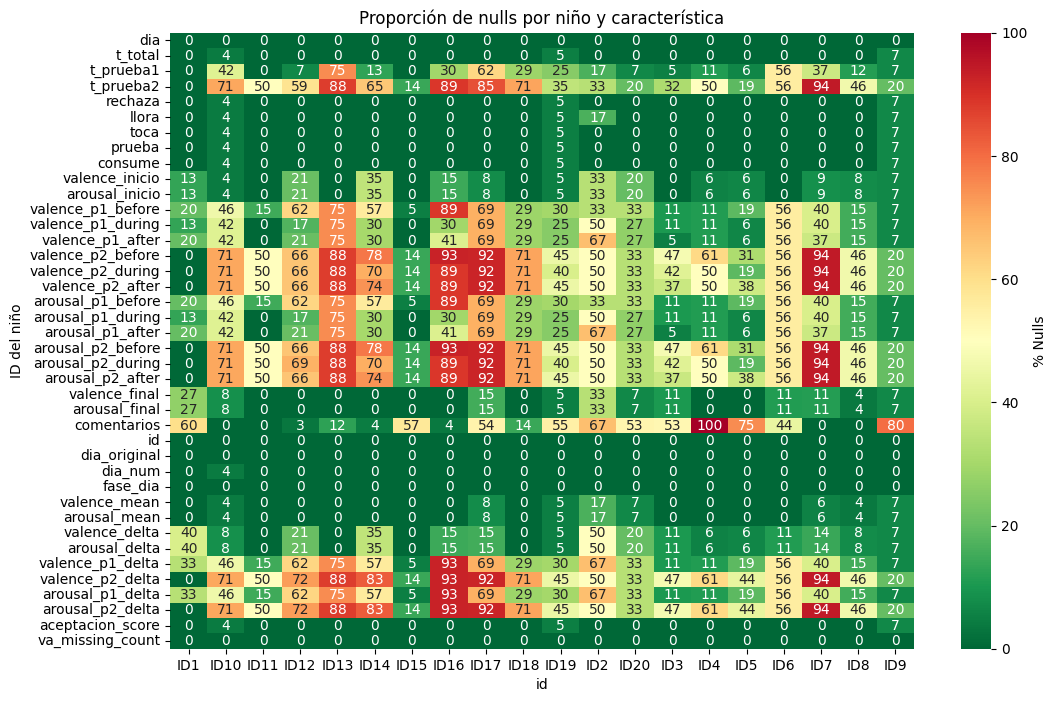

In [117]:
nulls_per_child =  pd.DataFrame(df_limpio.groupby('id').apply(lambda x: x.isnull().sum()/ len(x)*100).T).round(2)
plt.figure(figsize=(12, 8))
sns.heatmap(nulls_per_child, annot=True, fmt='.0f', cmap='RdYlGn_r', cbar_kws={'label': '% Nulls'})
plt.title('Proporción de nulls por niño y característica')
plt.ylabel('ID del niño')
plt.show()

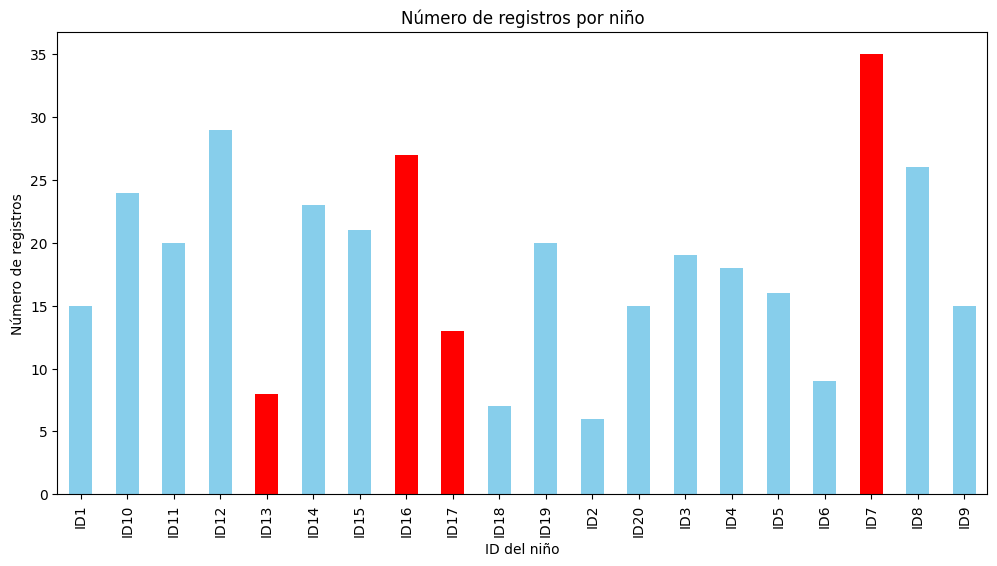

In [118]:
data_per_child = df_limpio.groupby('id').size()

# Crear lista de colores
colors = ['red' if idx in ["ID13", "ID16", "ID17", "ID7"] else 'skyblue' for idx in data_per_child.index]

# Graficar
data_per_child.plot(kind='bar', figsize=(12, 6), color=colors)
plt.title('Número de registros por niño')
plt.xlabel('ID del niño')
plt.ylabel('Número de registros')
plt.show()

### 1. Matrices de Correlación — Pearson, Spearman y Kendall

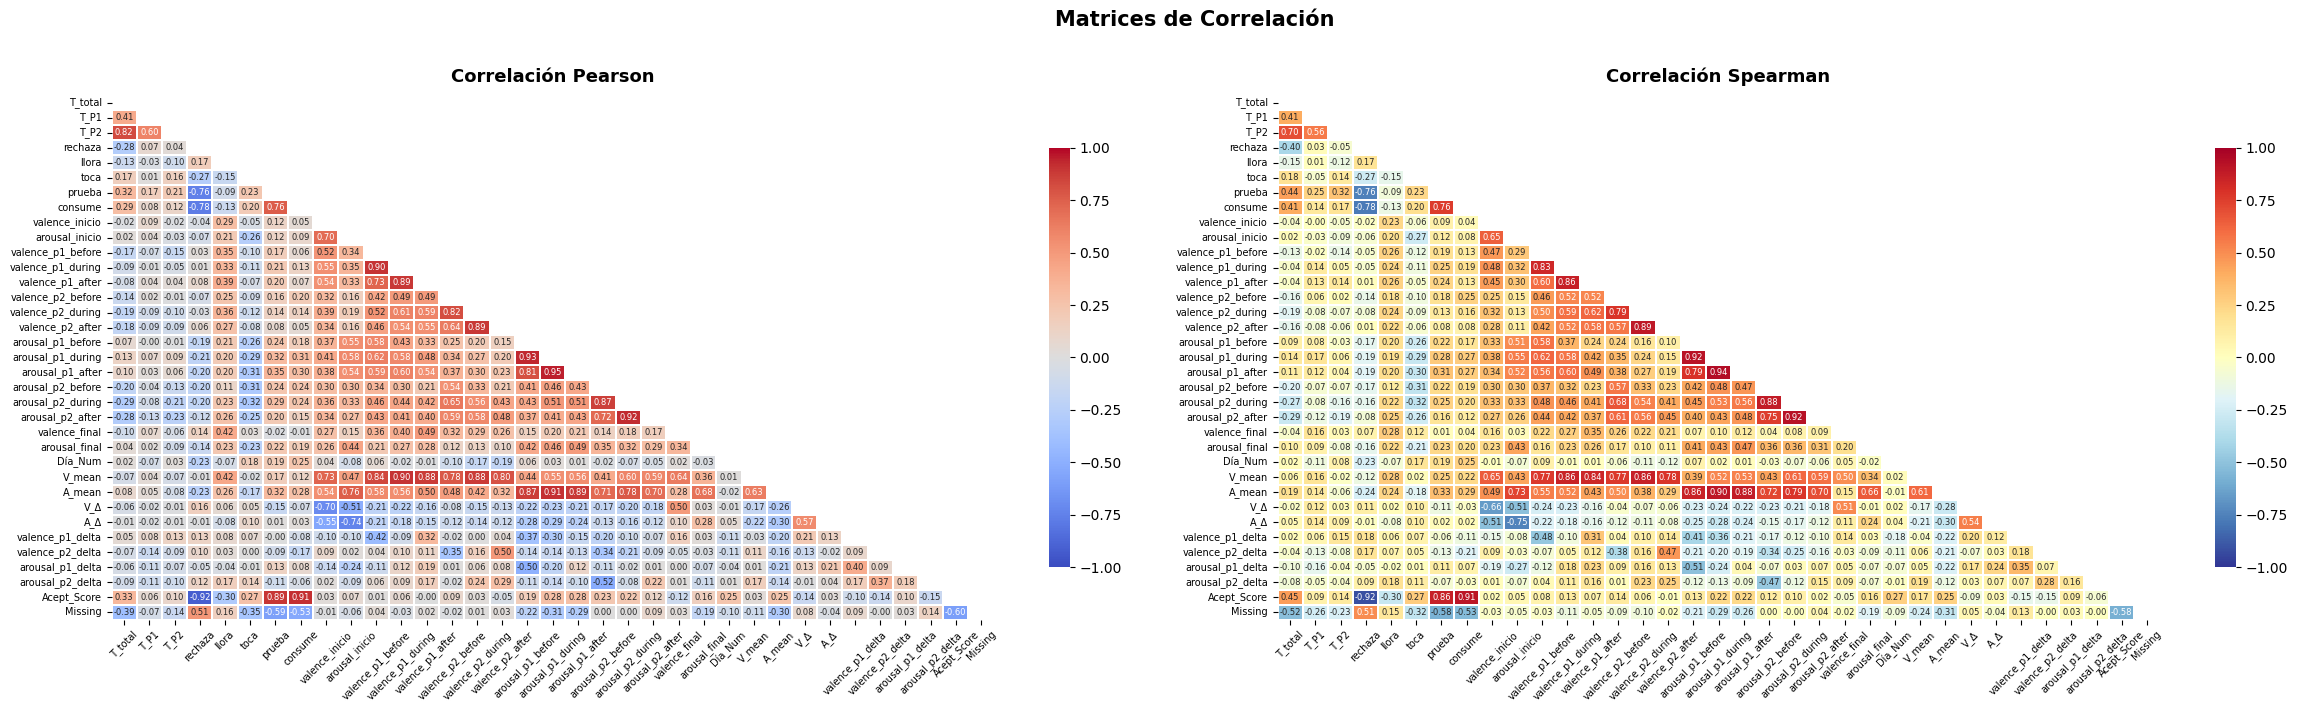

In [130]:
def rename_corr(corr_df):
    """Renombra columnas para mayor legibilidad"""
    abbreviations = {
        'valence_mean': 'V_mean',
        'arousal_mean': 'A_mean',
        'valence_delta': 'V_Δ',
        'arousal_delta': 'A_Δ',
        'aceptacion_score': 'Acept_Score',
        'va_missing_count': 'Missing',
        't_total': 'T_total',
        't_prueba1': 'T_P1',
        't_prueba2': 'T_P2',
        'dia_num': 'Día_Num',
    }
    return corr_df.rename(columns=abbreviations, index=abbreviations)

# Calcular correlaciones
df_numeric = df_limpio.select_dtypes(include=[np.number])
corr_pearson = df_numeric.corr(method='pearson')
corr_spearman = df_numeric.corr(method='spearman')

# Crear gráficos
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
fig, axes = plt.subplots(1, 2, figsize=(24, 7))

metodos = [
    ('Pearson', rename_corr(corr_pearson), 'coolwarm'),
    ('Spearman', rename_corr(corr_spearman), 'RdYlBu_r'),
]

for ax, (titulo, corr, cmap) in zip(axes, metodos):
    sns.heatmap(corr, ax=ax, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
                annot=True, fmt='.2f', annot_kws={'size': 6},
                linewidths=0.3, linecolor='white', cbar_kws={'shrink': 0.8})
    ax.set_title(f'Correlación {titulo}', fontsize=13, fontweight='bold', pad=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle('Matrices de Correlación', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2. Heatmaps con Clustering Jerárquico

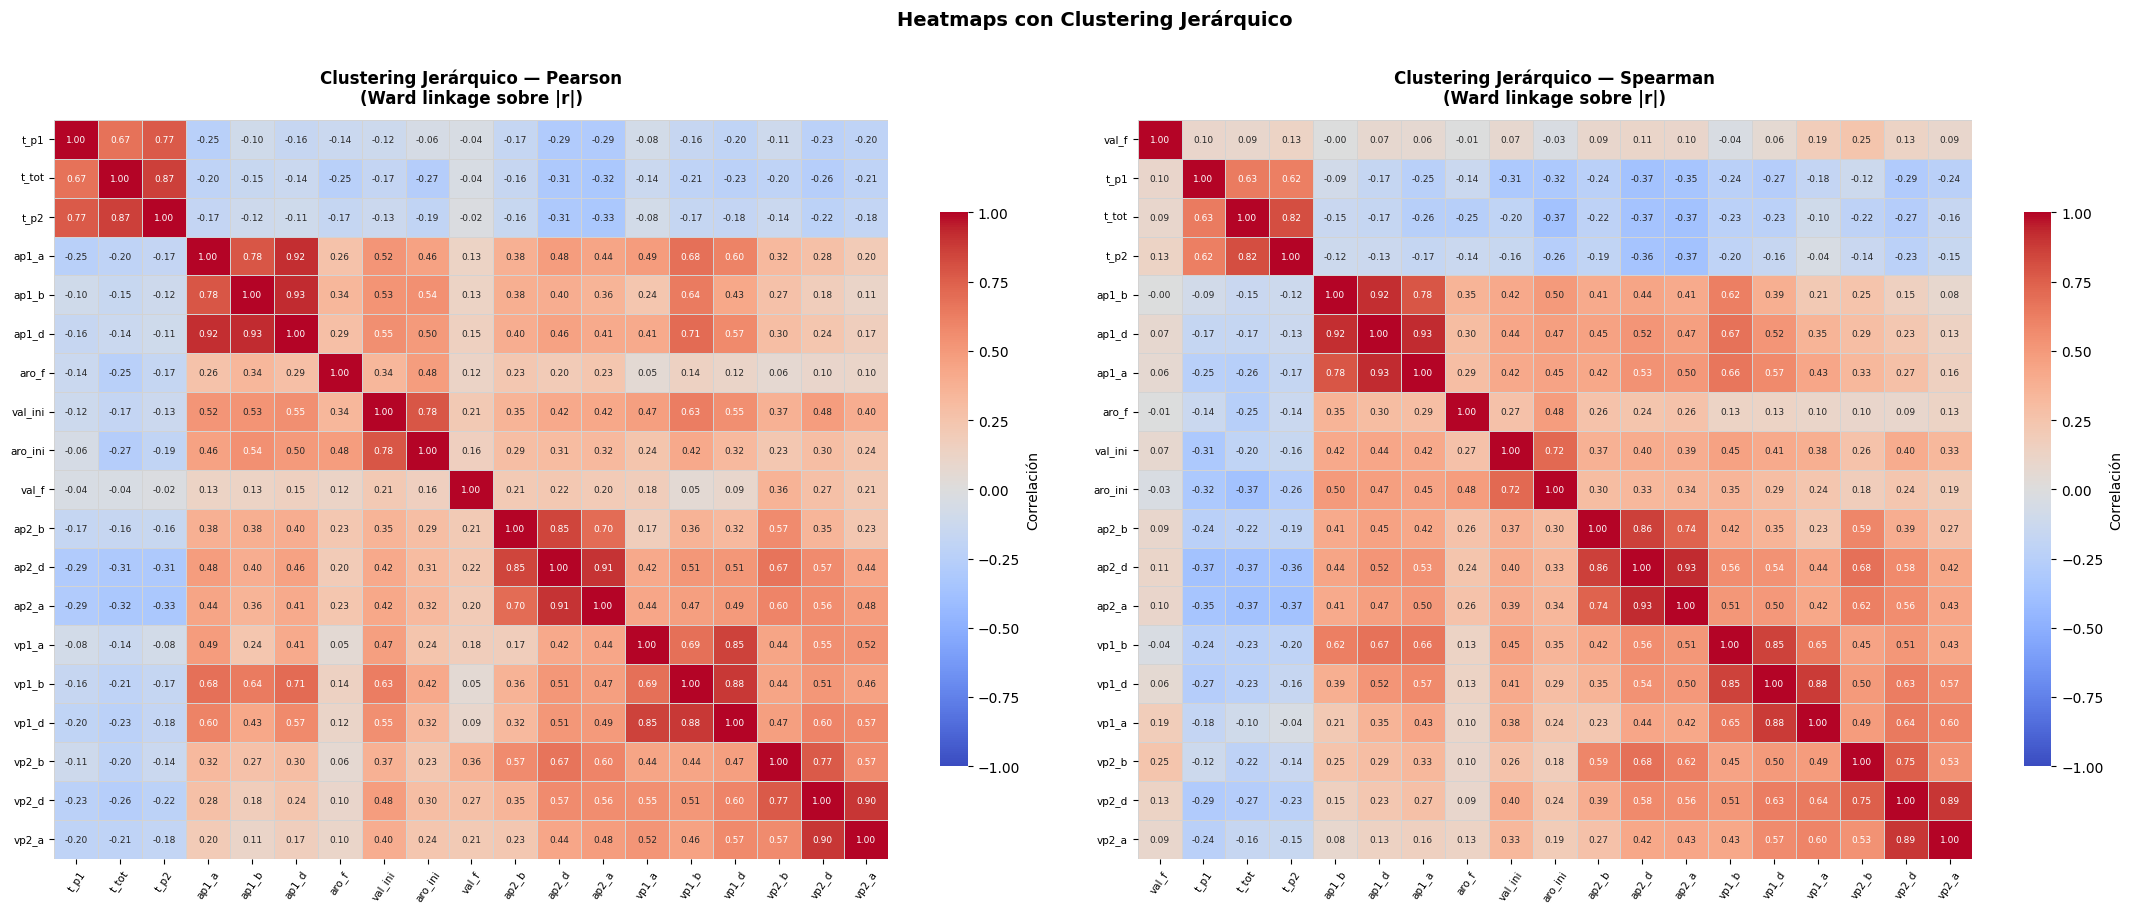

In [ ]:
from scipy.cluster.hierarchy import leaves_list

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, (nombre, corr_mat) in zip(axes, [('Pearson', corr_pearson), ('Spearman', corr_spearman)]):
    dist = 1 - corr_mat.abs()
    np.fill_diagonal(dist.values, 0)
    lm = linkage(squareform(dist.values), method='ward')
    orden = leaves_list(lm)
    corr_ord = rename_corr(corr_mat).iloc[orden, :].iloc[:, orden]
    sns.heatmap(corr_ord, ax=ax, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                annot=True, fmt='.2f', annot_kws={'size': 6.5},
                linewidths=0.4, linecolor='lightgrey',
                cbar_kws={'shrink': 0.75, 'label': 'Correlación'})
    ax.set_title(f'Clustering Jerárquico — {nombre}\n(Ward linkage sobre |r|)',
                 fontsize=12, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=55, labelsize=7.5)
    ax.tick_params(axis='y', rotation=0,  labelsize=7.5)

plt.suptitle('Heatmaps con Clustering Jerárquico', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3. Scatter Plots Multivariados con Color y Tamaño

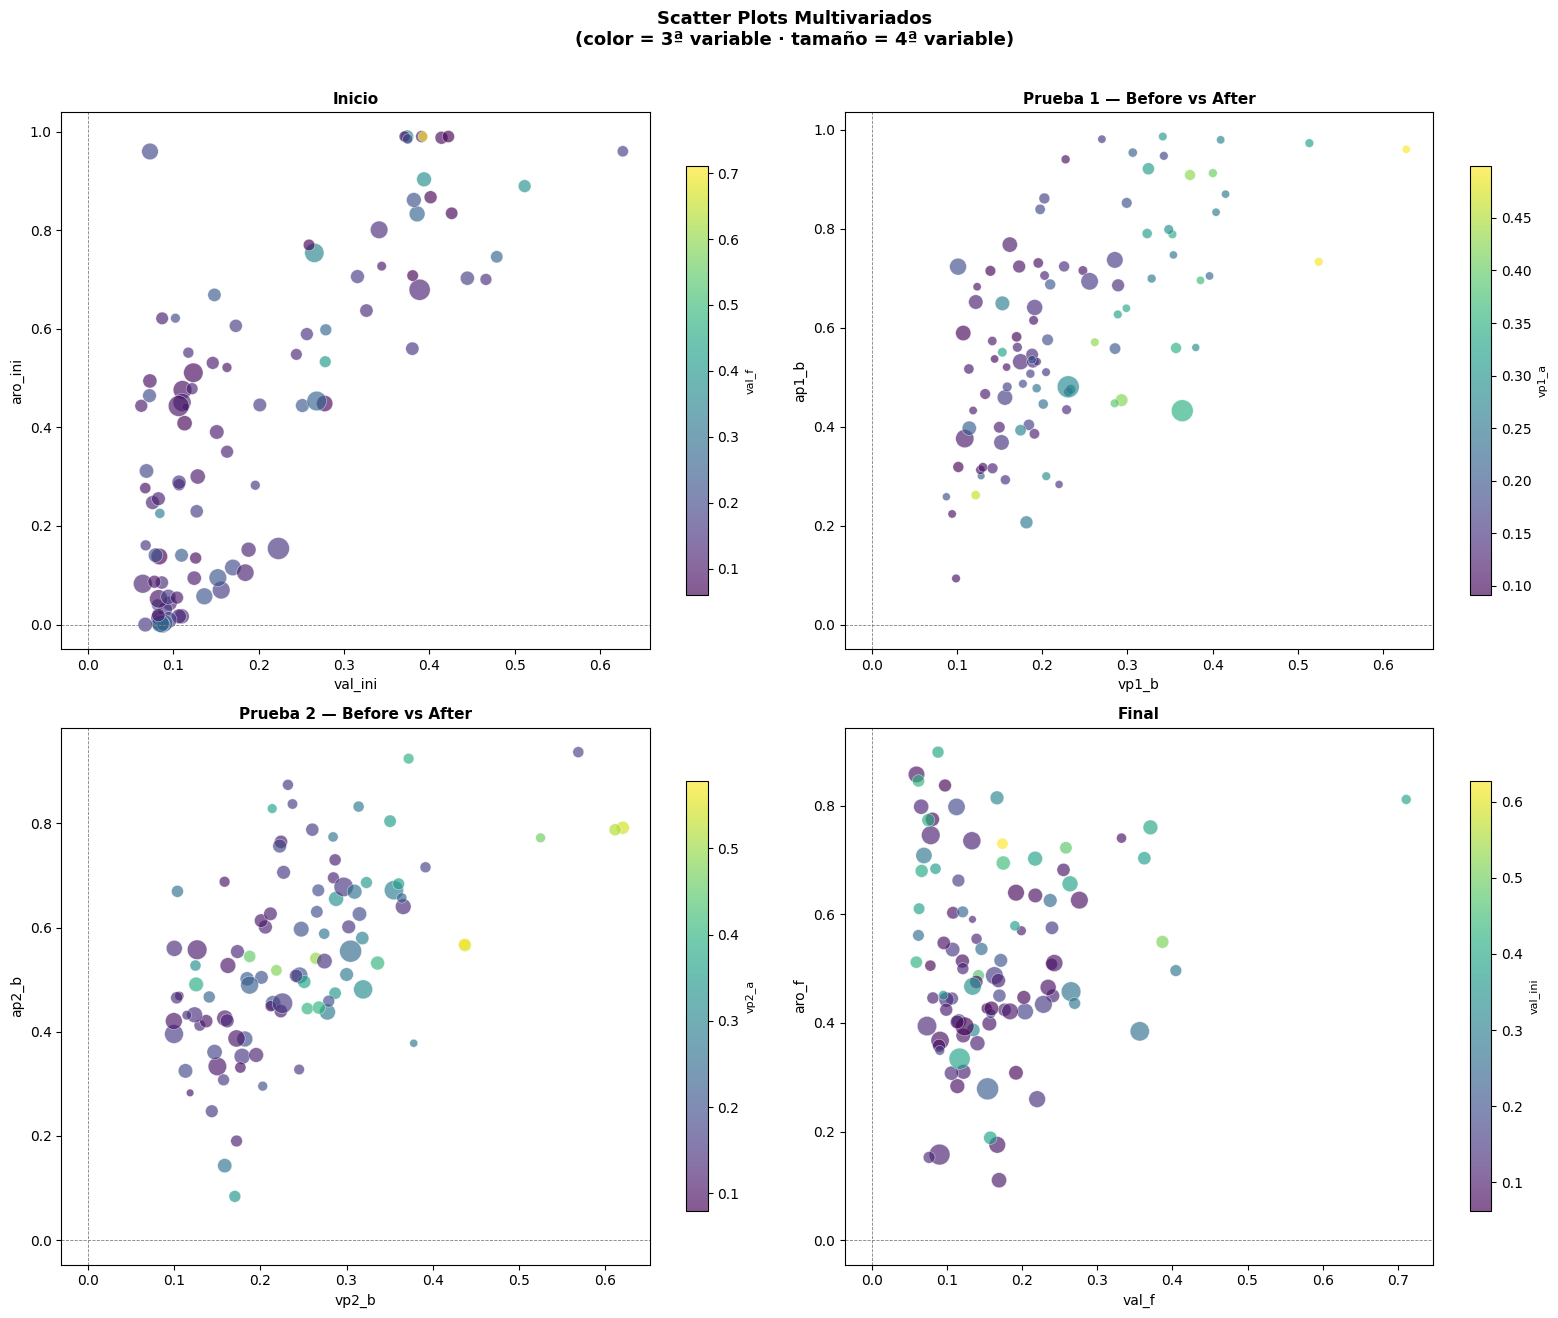

In [ ]:
df_scatter = df[cols_numericas + cols_binarias].dropna(subset=cols_numericas)
pares = [
    ('valence_inicio',    'arousal_inicio',    'valence_final',   't_total',   'Inicio'),
    ('valence_p1_before', 'arousal_p1_before', 'valence_p1_after','t_prueba1', 'Prueba 1 — Before vs After'),
    ('valence_p2_before', 'arousal_p2_before', 'valence_p2_after','t_prueba2', 'Prueba 2 — Before vs After'),
    ('valence_final',     'arousal_final',     'valence_inicio',  't_total',   'Final'),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()
cmap_sc = plt.cm.viridis

for ax, (x_col, y_col, color_col, size_col, titulo) in zip(axes, pares):
    sub = df_scatter[[x_col, y_col, color_col, size_col]].dropna()
    s_norm = (sub[size_col] - sub[size_col].min()) / (sub[size_col].max() - sub[size_col].min() + 1e-9)
    sizes = 30 + s_norm * 220
    sc = ax.scatter(sub[x_col], sub[y_col], c=sub[color_col], s=sizes,
                    cmap=cmap_sc, alpha=0.65, edgecolors='white', linewidths=0.4)
    plt.colorbar(sc, ax=ax, shrink=0.8).set_label(labels_cortos.get(color_col, color_col), fontsize=8)
    ax.set_xlabel(labels_cortos.get(x_col, x_col), fontsize=10)
    ax.set_ylabel(labels_cortos.get(y_col, y_col), fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.axhline(0, color='grey', lw=0.6, ls='--')
    ax.axvline(0, color='grey', lw=0.6, ls='--')

plt.suptitle('Scatter Plots Multivariados\n(color = 3ª variable · tamaño = 4ª variable)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4. Pairplots — Subconjuntos Estratégicos

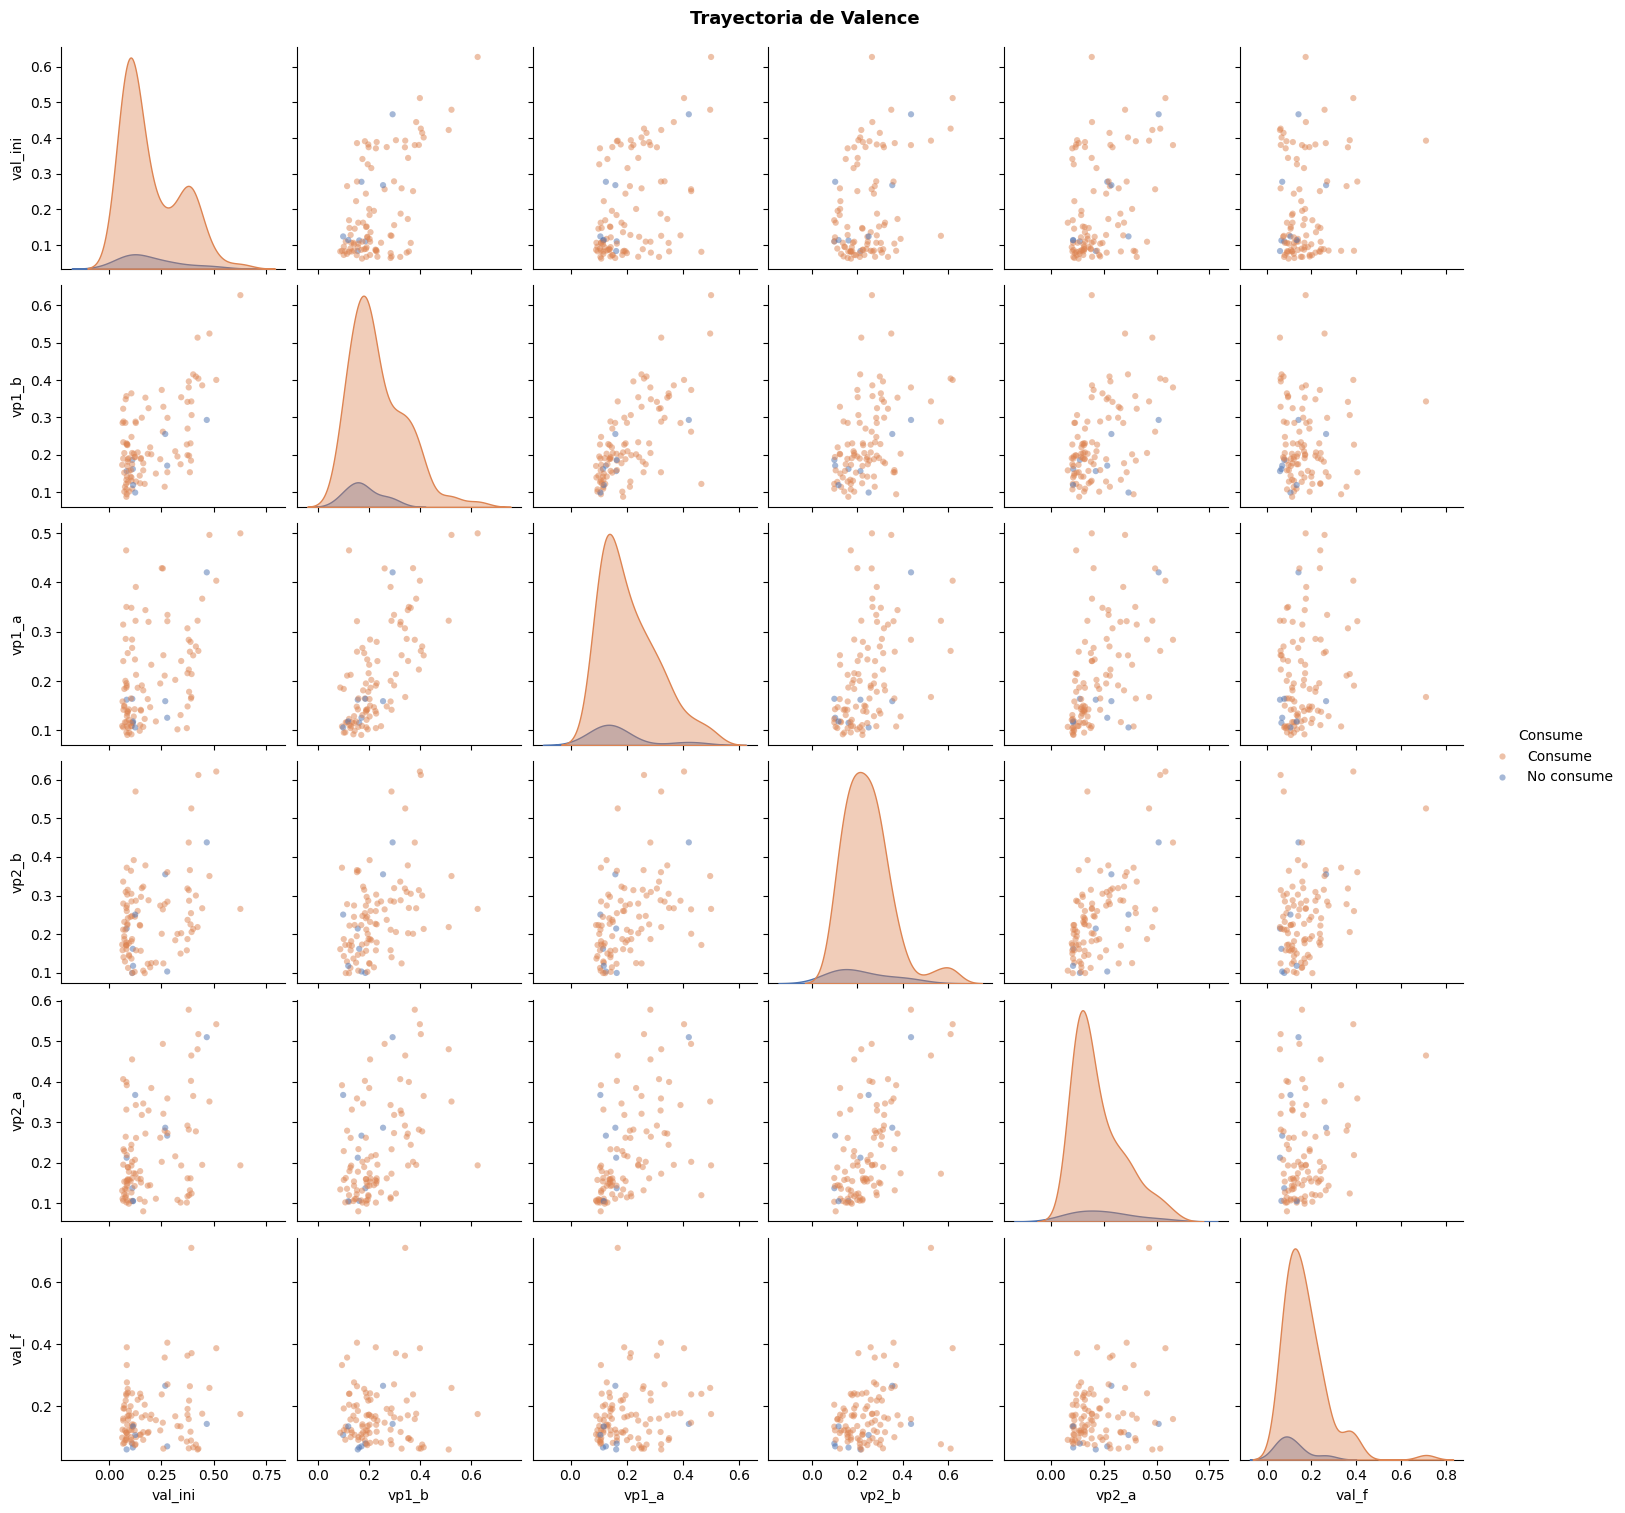

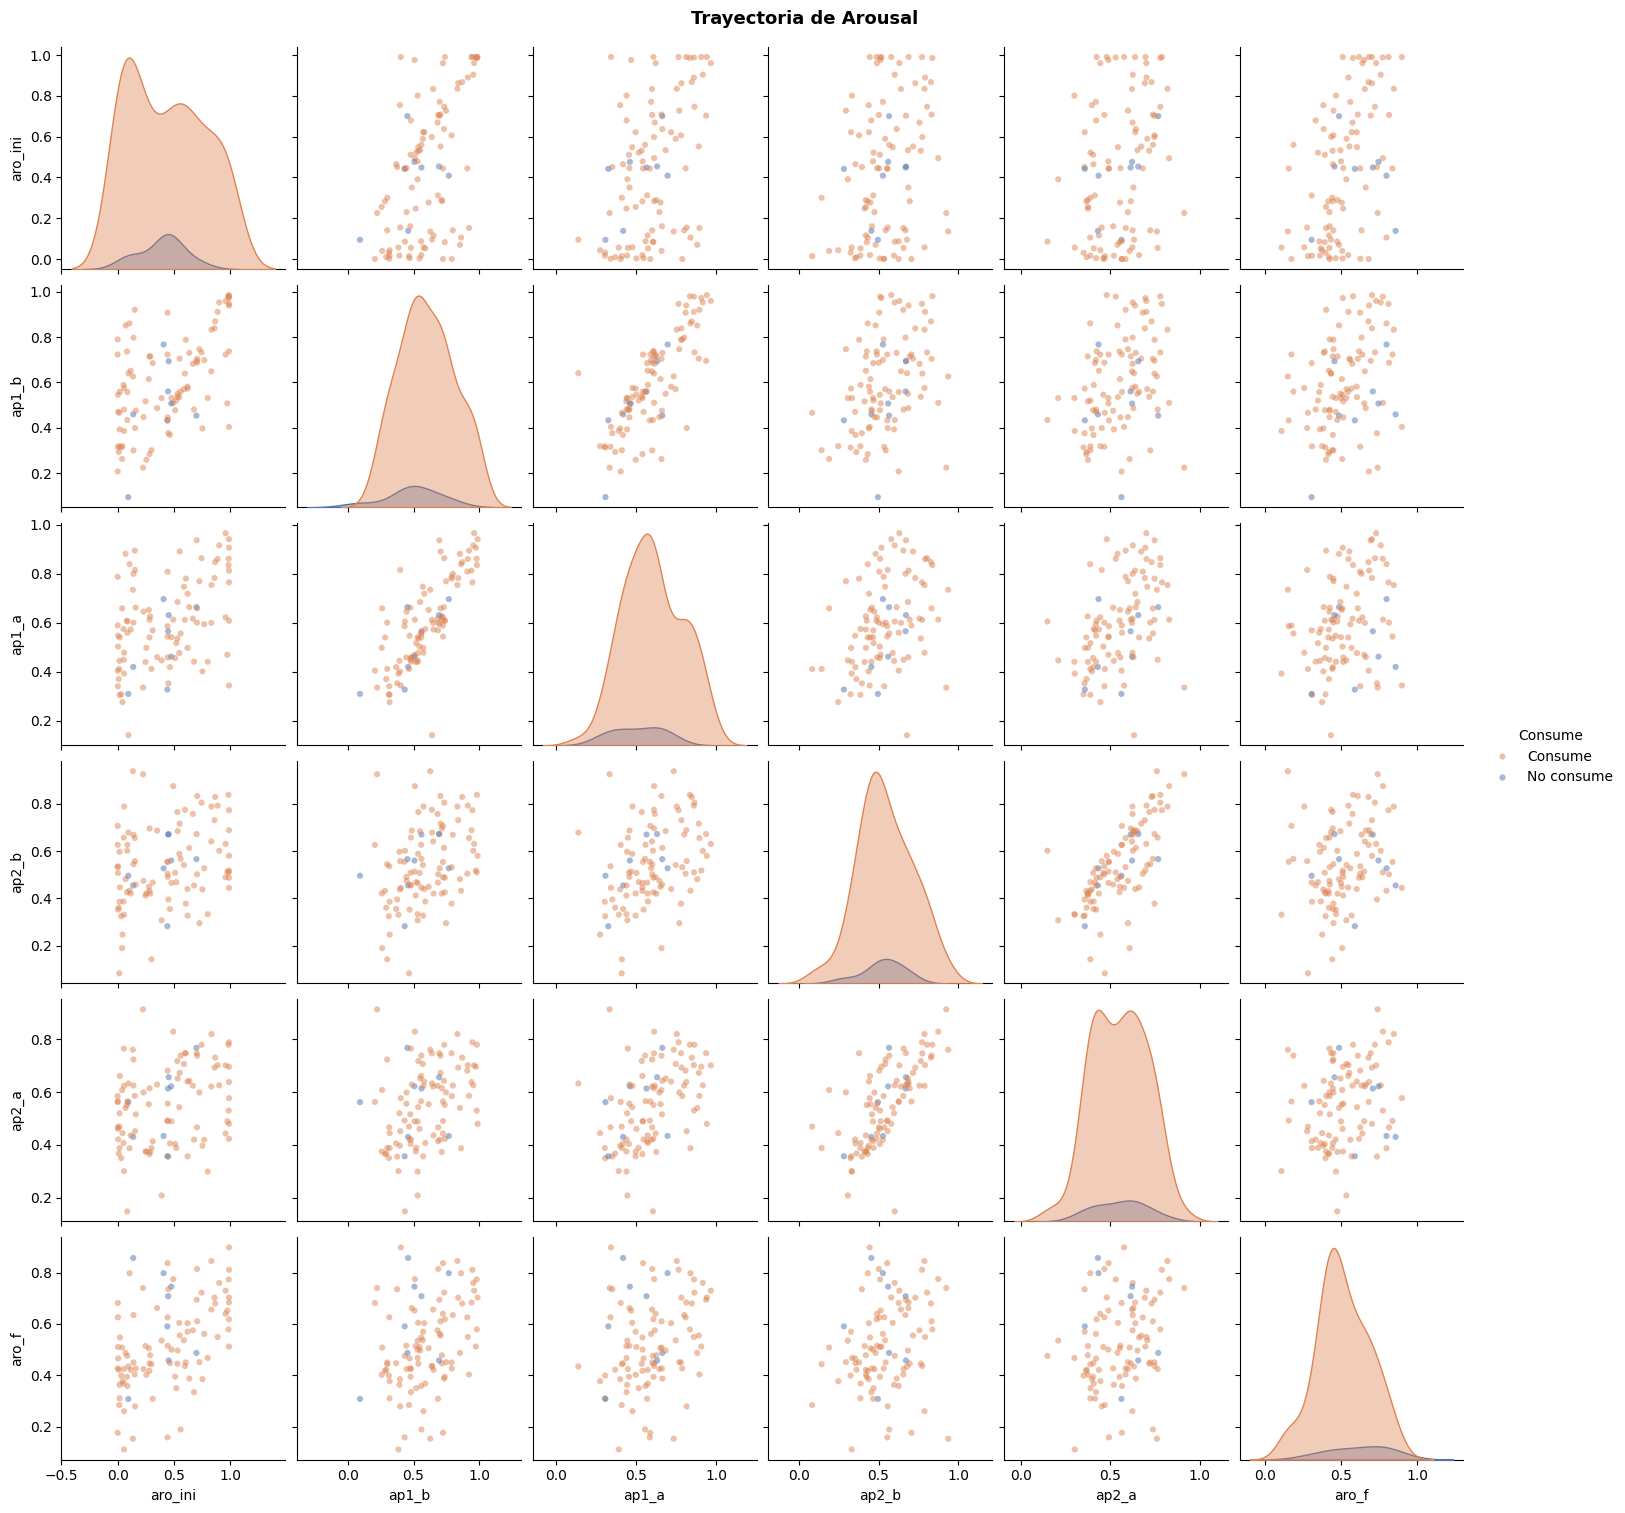

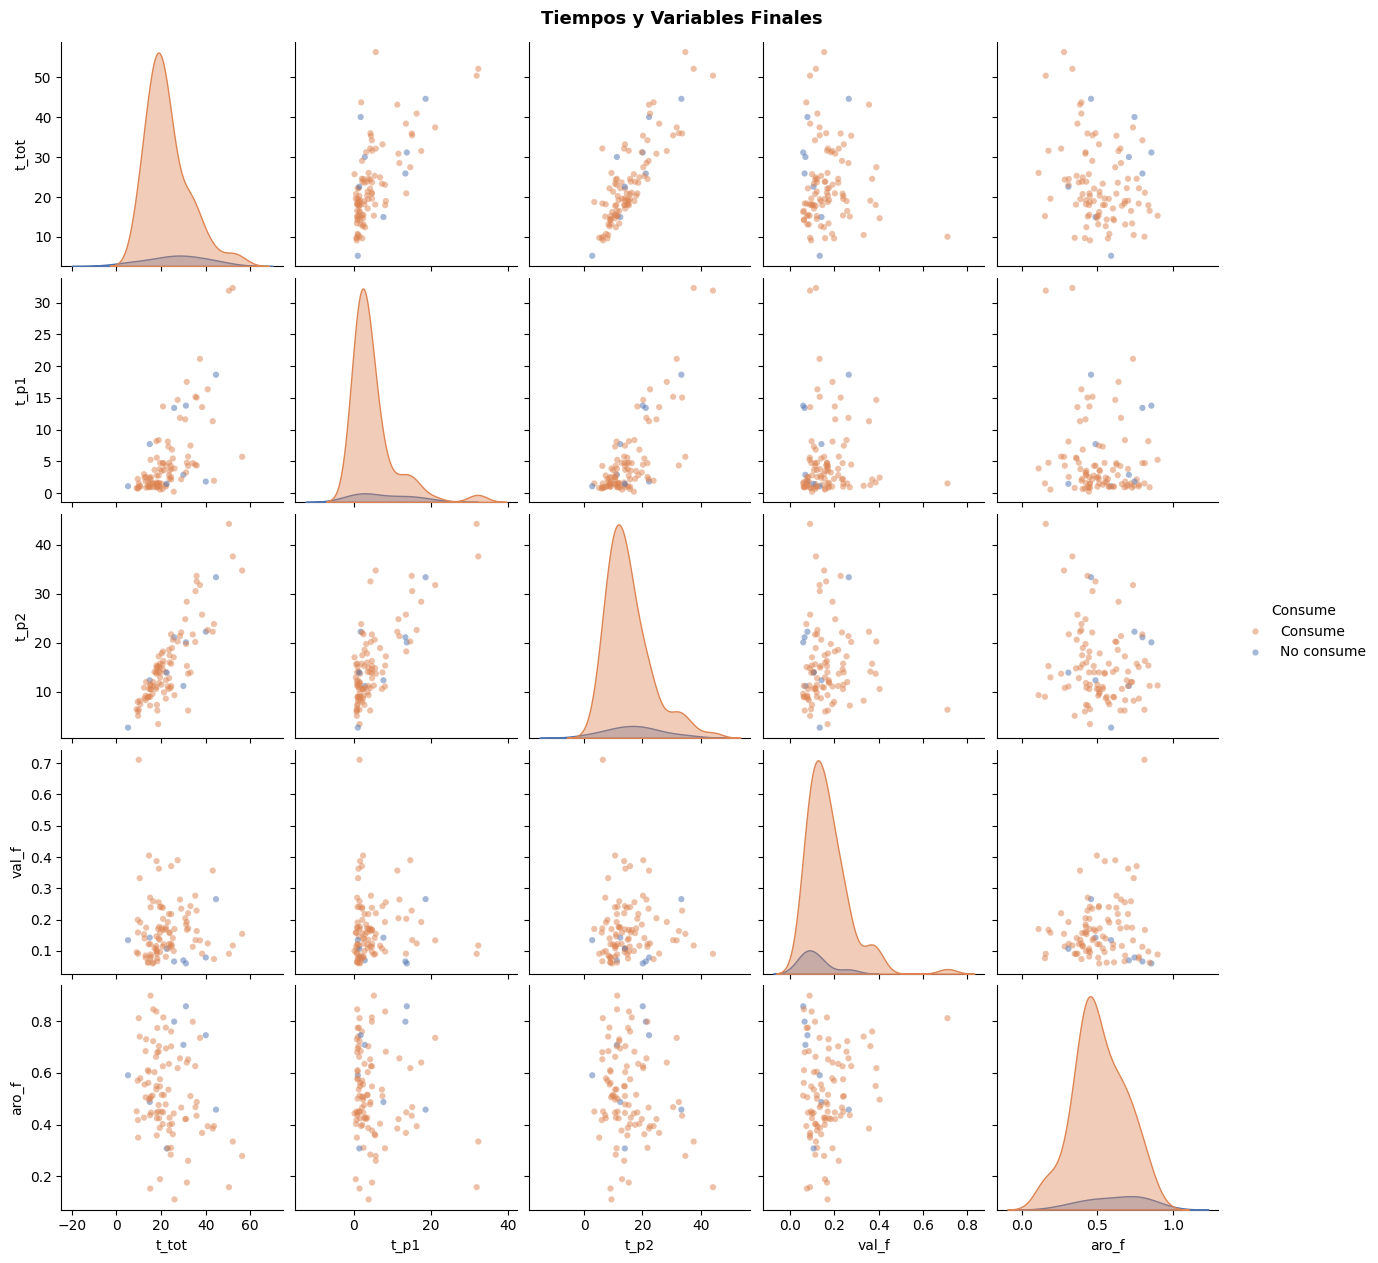

In [ ]:
cols_valence = ['valence_inicio','valence_p1_before','valence_p1_after',
                'valence_p2_before','valence_p2_after','valence_final']
cols_arousal = ['arousal_inicio','arousal_p1_before','arousal_p1_after',
                'arousal_p2_before','arousal_p2_after','arousal_final']
cols_tiempos = ['t_total','t_prueba1','t_prueba2','valence_final','arousal_final']

todas_cols = list(set(cols_valence + cols_arousal + cols_tiempos + ['consume']))
df_pp = df[todas_cols].dropna().copy()
df_pp['consume_cat'] = df_pp['consume'].map({0: 'No consume', 1: 'Consume'})

for cols, titulo, fname in [
    (cols_valence, 'Trayectoria de Valence',     'pairplot_valence'),
    (cols_arousal, 'Trayectoria de Arousal',     'pairplot_arousal'),
    (cols_tiempos, 'Tiempos y Variables Finales','pairplot_tiempos'),
]:
    rename_map = {c: labels_cortos.get(c, c) for c in cols}
    df_plot = df_pp[cols + ['consume_cat']].rename(columns=rename_map)
    g = sns.pairplot(
        df_plot, vars=[rename_map[c] for c in cols], hue='consume_cat',
        palette={'No consume': '#4C72B0', 'Consume': '#DD8452'},
        diag_kind='kde',
        plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'none'},
        diag_kws={'fill': True, 'alpha': 0.4}
    )
    g.figure.suptitle(titulo, y=1.01, fontsize=13, fontweight='bold')
    g._legend.set_title('Consume')
    plt.show()

### 5. Gráficos de Dispersión 3D (Plotly interactivo)

In [19]:
df_3d = df[cols_numericas + ['consume','llora']].dropna(subset=cols_numericas).copy()
df_3d['consume_cat'] = df_3d['consume'].fillna(0).map({0: 'No consume', 1: 'Consume'})
df_3d['llora_cat']   = df_3d['llora'].fillna(0).map({0: 'No llora',    1: 'Llora'})

# Gráfico 1: Valence inicio → final vs Arousal final
fig1 = px.scatter_3d(df_3d, x='valence_inicio', y='valence_final', z='arousal_final',
    color='consume_cat', size='t_total', size_max=18, opacity=0.7,
    color_discrete_map={'No consume':'#4C72B0','Consume':'#DD8452'},
    title='3D: Valence Inicio→Final vs Arousal Final  |  color=Consume · tamaño=t_total')
fig1.update_layout(margin=dict(l=0,r=0,b=0,t=50))
fig1.show()

# Gráfico 2: Arousal inicio → final vs Tiempo total
fig2 = px.scatter_3d(df_3d, x='arousal_inicio', y='arousal_final', z='t_total',
    color='llora_cat', size='t_prueba1', size_max=18, opacity=0.7,
    color_discrete_map={'No llora':'#55A868','Llora':'#C44E52'},
    title='3D: Arousal Inicio→Final vs Tiempo Total  |  color=Llora · tamaño=t_prueba1')
fig2.update_layout(margin=dict(l=0,r=0,b=0,t=50))
fig2.show()

# Gráfico 3: Valence P1 vs P2 during, color continuo de Arousal P2
fig3 = px.scatter_3d(df_3d, x='valence_p1_during', y='valence_p2_during', z='arousal_p1_during',
    color='arousal_p2_during', size='t_total', size_max=15, opacity=0.75,
    color_continuous_scale='Viridis',
    title='3D: Valence P1 vs P2 During  |  color=Arousal P2 · tamaño=t_total')
fig3.update_layout(margin=dict(l=0,r=0,b=0,t=50))
fig3.show()